# Figures
This notebook provides the codes to create the figures used in the thesis and in the presentation

*The Code in this notebook was written with the help of AI (Gemini, Version 3.1 Pro)*

## 1. Weighted Regression Plot
This code imports the weighted regression data between the SLA data and NIR data and then plots the WLS and OLS trendline. The observation points are colored by their Landsat/Sentinel-2 confidence weight.

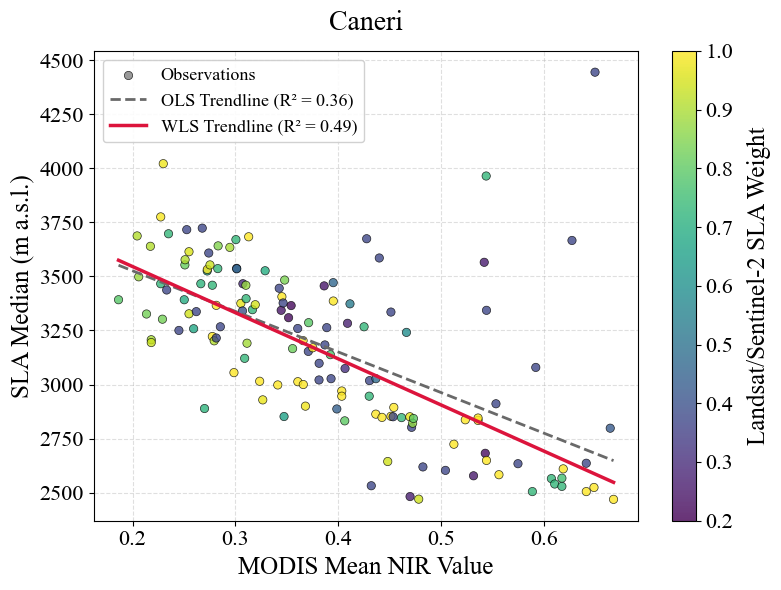

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load data
clean_data_dir = '../Results/Weighted_regression/clean_datasets'
summary_path = '../Results/Weighted_regression/Regression_Comparison.csv'

df_summary = pd.read_csv(summary_path)
clean_datasets = {}
for f in os.listdir(clean_data_dir):
    if f.endswith('.csv'):
        name = f.replace('clean_', '').replace('.csv', '')
        clean_datasets[name] = pd.read_csv(f"{clean_data_dir}/{f}")

# Font type and size
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 13,
    "figure.titlesize": 20
})

# Plot
GLACIER_TO_PLOT = 'Caneri'

if GLACIER_TO_PLOT in clean_datasets:
    clean_df = clean_datasets[GLACIER_TO_PLOT].copy()
    clean_df = clean_df.sort_values(by='meanNIR')

    stats = df_summary[df_summary['Glacier'] == GLACIER_TO_PLOT].iloc[0]

    wls_slope = stats['Slope Weighted']
    wls_intercept = stats['Intercept Weighted']
    ols_slope = stats['Slope Unweighted']
    ols_intercept = stats['Intercept Unweighted']

    clean_df['trendline_weighted'] = clean_df['meanNIR'] * wls_slope + wls_intercept
    clean_df['trendline_unweighted'] = clean_df['meanNIR'] * ols_slope + ols_intercept

    fig, ax = plt.subplots(figsize=(8, 6))

    scatter = ax.scatter(
        clean_df['meanNIR'],
        clean_df['SLA_MP-median'],
        c=clean_df['LS_weight_final'],
        cmap='viridis',
        vmin=0.2,
        vmax=1.0,
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5,
        zorder=2
    )
    ax.scatter([], [], c='gray', alpha=0.8, edgecolor='black', linewidth=0.5, label='Observations')

    ax.plot(
        clean_df['meanNIR'],
        clean_df['trendline_unweighted'],
        color='dimgray',
        linewidth=2,
        linestyle='--',
        zorder=3,
        label=f'OLS Trendline (R² = {stats["R² Unweighted"]:.2f})'
    )
    ax.plot(
        clean_df['meanNIR'],
        clean_df['trendline_weighted'],
        color='crimson',
        linewidth=2.5,
        zorder=4,
        label=f'WLS Trendline (R² = {stats["R² Weighted"]:.2f})'
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Landsat/Sentinel-2 SLA Weight", labelpad=10)

    ax.set_xlabel("MODIS Mean NIR Value")
    ax.set_ylabel("SLA Median (m a.s.l.)")
    ax.set_title(f"{GLACIER_TO_PLOT}", pad=15)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
    ax.legend(loc='upper left', framealpha=0.9)
    plt.tight_layout()
    plt.show()

    #output_path = f"../results/Weighted_regression/weighted_regression_{GLACIER_TO_PLOT}.png"
    #fig.savefig(output_path, dpi=300, bbox_inches='tight')

## 2. Multiple plots weighted regression
This code plots the weighted regression for a subset of glaciers selected, all in one figure. Here it is used to create the figures to add in the appendix. 

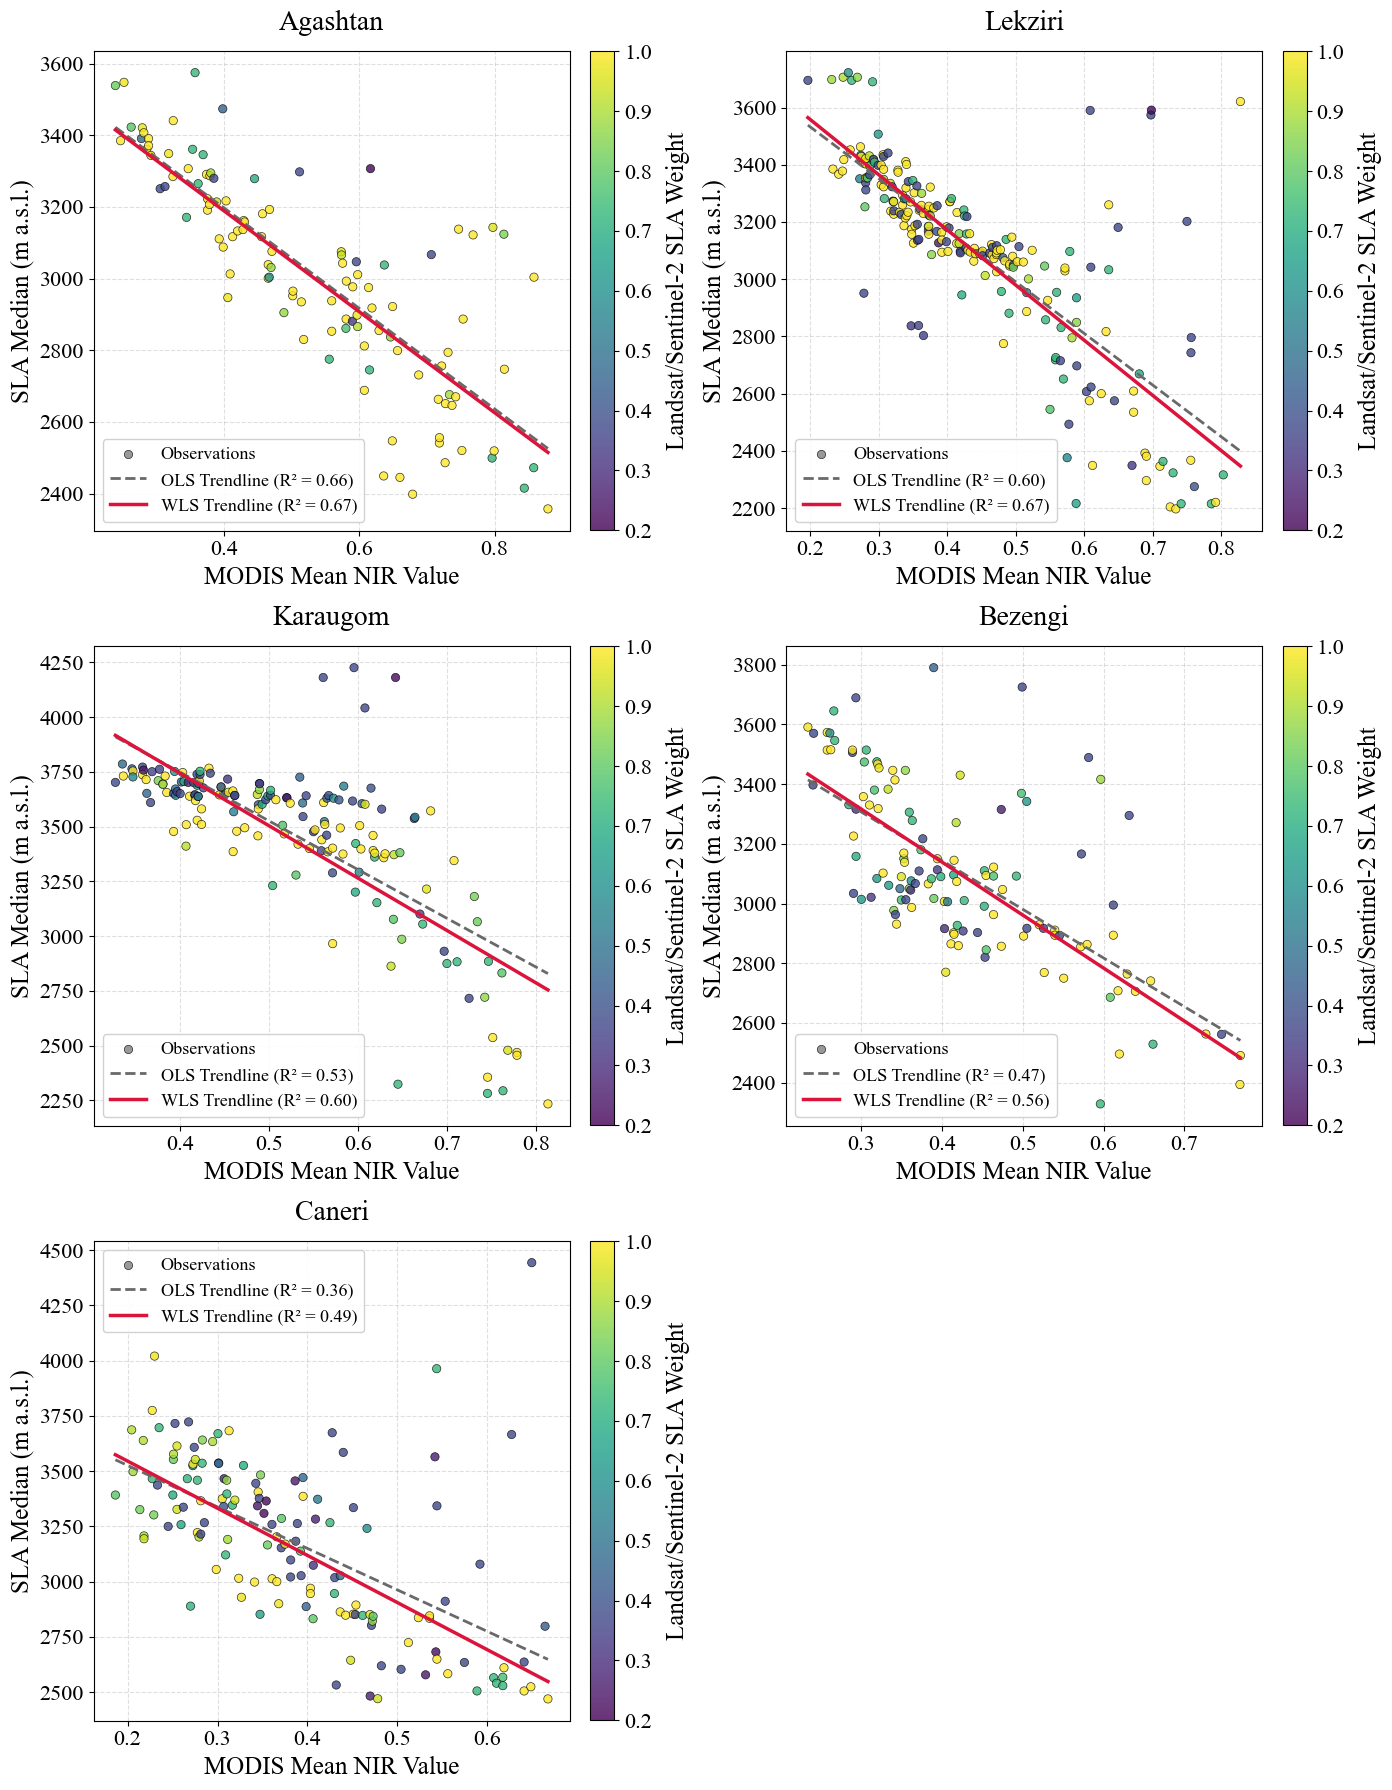

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load data
clean_data_dir = '../Results/Weighted_regression/clean_datasets'
summary_path = '../Results/Weighted_regression/Regression_Comparison.csv'
df_summary = pd.read_csv(summary_path)
clean_datasets = {}
for f in os.listdir(clean_data_dir):
    if f.endswith('.csv'):
        name = f.replace('clean_', '').replace('.csv', '')
        clean_datasets[name] = pd.read_csv(f"{clean_data_dir}/{f}")

# Font type and size
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 13,
    "figure.titlesize": 20
})

# Select glaciers
appendix_glaciers = ['Agashtan', 'Lekziri', 'Karaugom', 'Bezengi', 'Caneri']

# 3x2 grid (6th subplot hidden)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, glacier in enumerate(appendix_glaciers):
    ax = axes[i]

    if glacier in clean_datasets:
        clean_df = clean_datasets[glacier].copy()
        clean_df = clean_df.sort_values(by='meanNIR')

        stats = df_summary[df_summary['Glacier'] == glacier].iloc[0]

        wls_slope = stats['Slope Weighted']
        wls_intercept = stats['Intercept Weighted']
        ols_slope = stats['Slope Unweighted']
        ols_intercept = stats['Intercept Unweighted']

        clean_df['trendline_weighted'] = clean_df['meanNIR'] * wls_slope + wls_intercept
        clean_df['trendline_unweighted'] = clean_df['meanNIR'] * ols_slope + ols_intercept

        # Main scatter
        scatter = ax.scatter(
            clean_df['meanNIR'],
            clean_df['SLA_MP-median'],
            c=clean_df['LS_weight_final'],
            cmap='viridis',
            vmin=0.2,
            vmax=1.0,
            alpha=0.8,
            edgecolor='black',
            linewidth=0.5,
            zorder=2
        )

        # Proxy for legend
        ax.scatter([], [], c='gray', alpha=0.8, edgecolor='black', linewidth=0.5, label='Observations')

        # OLS trendline
        ax.plot(
            clean_df['meanNIR'],
            clean_df['trendline_unweighted'],
            color='dimgray',
            linewidth=2,
            linestyle='--',
            zorder=3,
            label=f'OLS Trendline (R² = {stats["R² Unweighted"]:.2f})'
        )

        # WLS trendline
        ax.plot(
            clean_df['meanNIR'],
            clean_df['trendline_weighted'],
            color='crimson',
            linewidth=2.5,
            zorder=4,
            label=f'WLS Trendline (R² = {stats["R² Weighted"]:.2f})'
        )

        # Colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Landsat/Sentinel-2 SLA Weight", labelpad=10)

        ax.set_xlabel("MODIS Mean NIR Value")
        ax.set_ylabel("SLA Median (m a.s.l.)")
        ax.set_title(f"{glacier}", pad=15)
        ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
        legend_loc = 'upper left' if glacier == 'Caneri' else 'lower left'
        ax.legend(loc=legend_loc, framealpha=0.9)

    else:
        ax.text(0.5, 0.5, f'No data for {glacier}', ha='center', va='center')

# Hide 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Export
output_path = '../Results/Weighted_regression/Appendix_Regressions.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')

## 3. Plot of the Seasonal Snowline of one specific glacier
The final combined SLA time series gets loaded and plotted for one specific glacier and one specific year. The MODIS and Landsat/Sentinel-2 data points get displayed in different colors. 

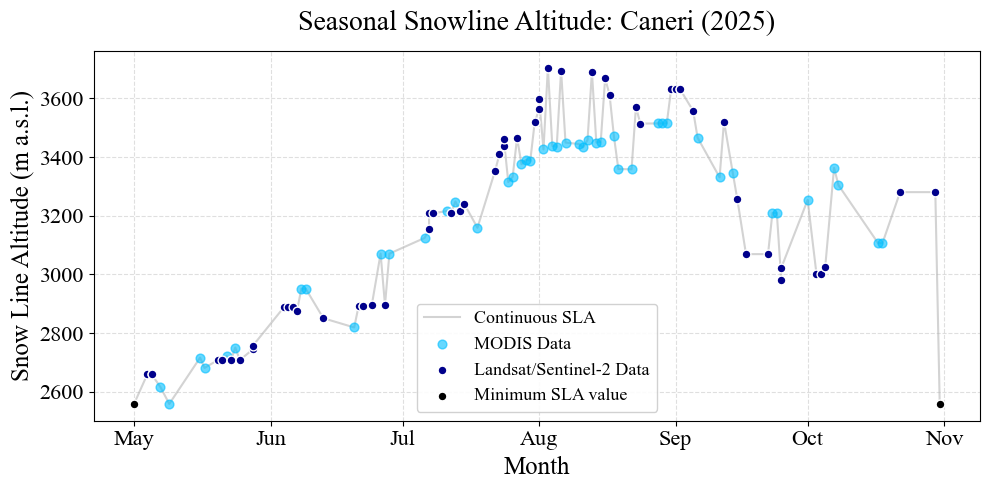

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Settings
GLACIER_TO_PLOT = 'Caneri'
TARGET_YEAR = 2025

# Load data
composite_path = f"../data/LS_MODIS_combined/combination_post2017/COMPOSITE_SLA_{GLACIER_TO_PLOT}_POST2017.csv"
df_comp = pd.read_csv(composite_path)
df_comp['date'] = pd.to_datetime(df_comp['date'])

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm", 
    "xtick.labelsize": 16,    
    "ytick.labelsize": 16,    
    "axes.labelsize": 18,     
    "axes.titlesize": 20,     
    "legend.fontsize": 13,    
    "figure.titlesize": 20    
})

# Filter for target year
df_year = df_comp[df_comp['date'].dt.year == TARGET_YEAR]

if df_year.empty:
    print(f"No data found for {GLACIER_TO_PLOT} in the year {TARGET_YEAR}.")
else:
    # Split the filtered data logically for coloring
    df_ls_year = df_year[df_year['Data_Source'] == 'Landsat/Sentinel (Observation)']
    df_modis_year = df_year[df_year['Data_Source'] == 'MODIS WLS (Proxy)']
    df_boundary_year = df_year[df_year['Data_Source'] == 'Assumed Full Snow Cover']

    # Create the Figure
    fig, ax = plt.subplots(figsize=(10, 5)) 

    # Trace 1: The Continuous Trajectory Line
    ax.plot(df_year['date'], df_year['Final_Composite_SLA'], 
            color='lightgrey', linewidth=1.5, label='Continuous SLA', zorder=1)

    # Trace 2: The MODIS Proxy Points
    ax.scatter(df_modis_year['date'], df_modis_year['Final_Composite_SLA'], 
               color='deepskyblue', s=40, alpha=0.6, label='MODIS Data', zorder=2)

    # Trace 3: The Landsat/Sentinel Data points
    ax.scatter(df_ls_year['date'], df_ls_year['Final_Composite_SLA'], 
               color='darkblue', s=40, edgecolor='white', linewidth=1, 
               label='Landsat/Sentinel-2 Data', zorder=3)
               
    # Trace 4: The Seasonal Boundaries 
    ax.scatter(df_boundary_year['date'], df_boundary_year['Final_Composite_SLA'], 
               color='black', s=40, edgecolor='white', linewidth=1,
               label='Minimum SLA value', zorder=4)

    # Layout and formatting
    ax.set_title(f"Seasonal Snowline Altitude: {GLACIER_TO_PLOT} ({TARGET_YEAR})", pad=15)
    ax.set_ylabel("Snow Line Altitude (m a.s.l.)")
    ax.set_xlabel("Month")
    
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    
    ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
    
    ax.legend(loc='lower center', framealpha=0.9)

    # keep the months horizontal
    ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    # Save the image
    output_filename = f"../results/Combined_SLA_timeseries/TimeSeries_{GLACIER_TO_PLOT}_{TARGET_YEAR}.png"
    fig.savefig(output_filename, dpi=300, bbox_inches='tight')

## 4. Plot Seasonal Snowline for all seven glaciers
Again the final time series get loaded, this time the 7 study glaciers get plotted together for one single year. This allows to compare the behavior of the different glaciers. The MODIS and Landsat/Sentinel-2 data points get displayed in different colors. 

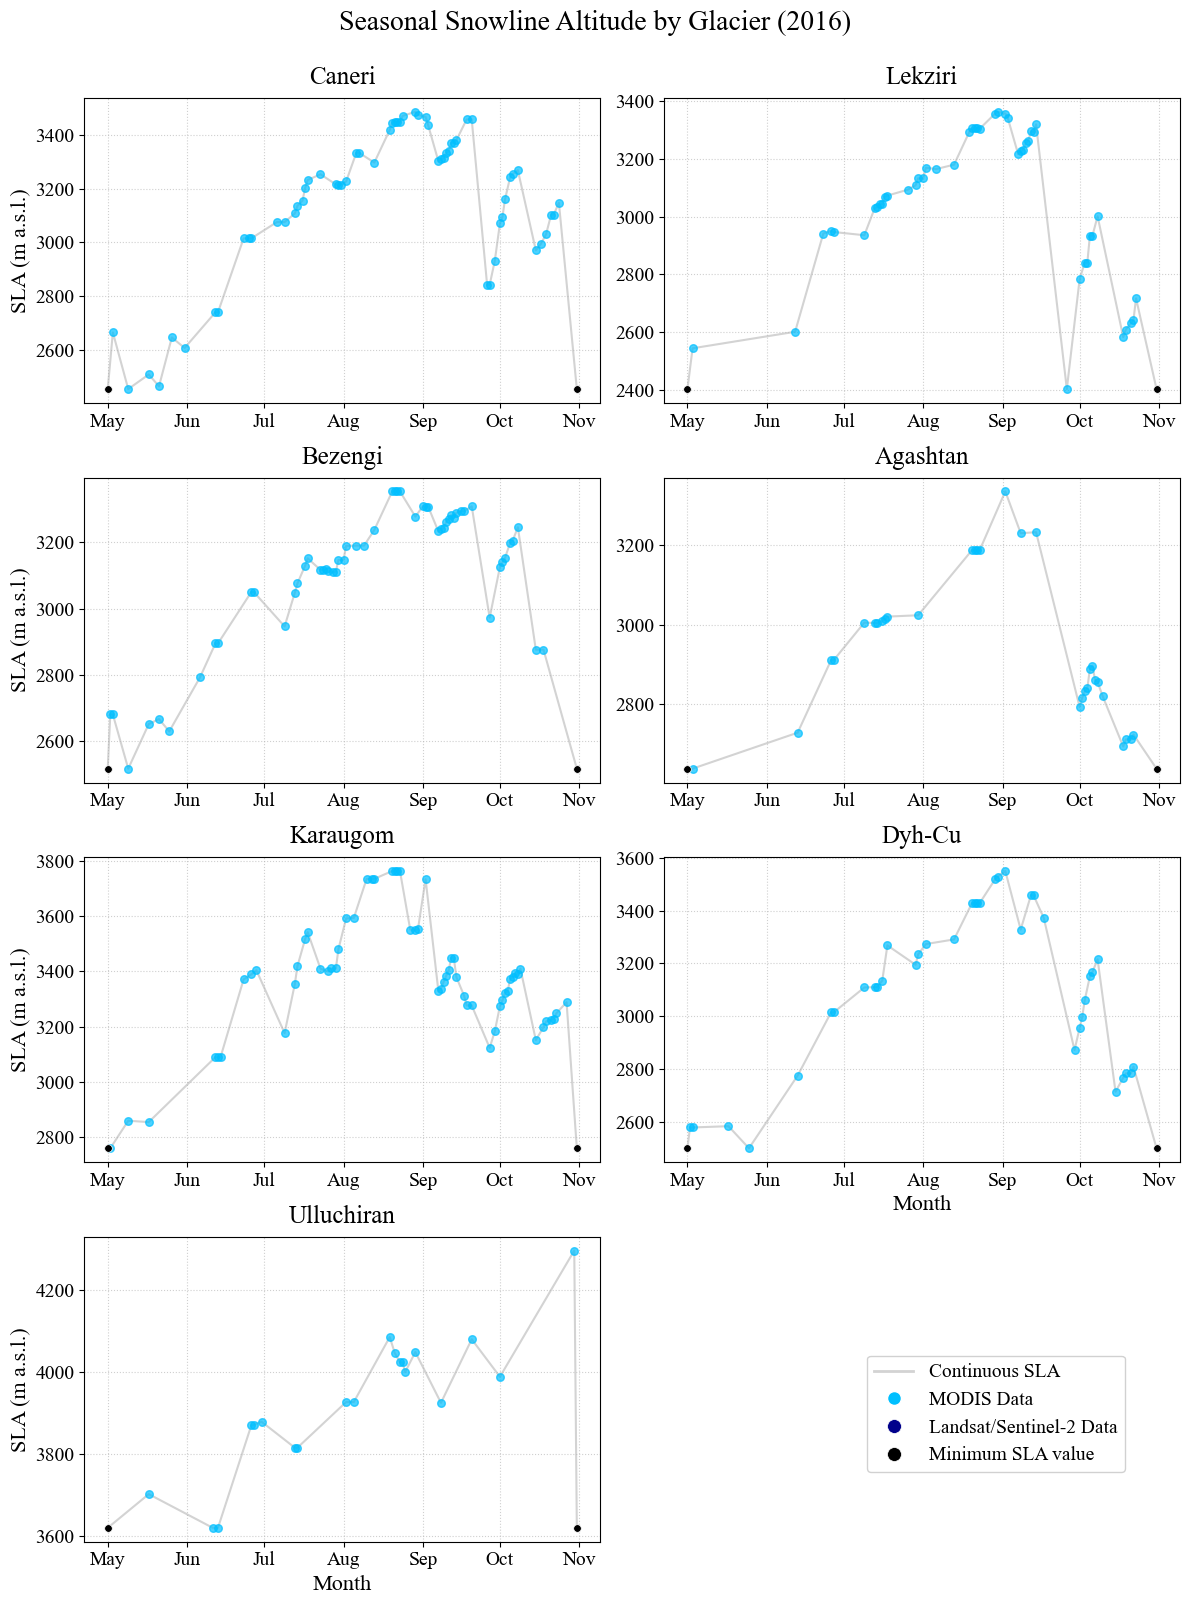

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from matplotlib.lines import Line2D

#Font type and size 
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm", 
    "xtick.labelsize": 14,    
    "ytick.labelsize": 14,    
    "axes.labelsize": 16,     
    "axes.titlesize": 18,     
    "legend.fontsize": 14,    
    "figure.titlesize": 20    
})

# Configuration
TARGET_YEAR = 2016
composite_dir = '../data/LS_MODIS_combined/combination_post2017'
study_glaciers = ['Caneri', 'Lekziri', 'Bezengi', 'Agashtan', 'Karaugom', 'Dyh-Cu', 'Ulluchiran']

# Build 4x2 Figure
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
axes = axes.flatten()

# Define which subplots get axis labels
left_col   = {0, 2, 4, 6}   # show y-axis label
bottom_row = {5, 6}          # show x-axis label 

for i, glacier in enumerate(study_glaciers):
    ax = axes[i]
    file_path = f"{composite_dir}/COMPOSITE_SLA_{glacier}_POST2017.csv"
    
    if os.path.exists(file_path):
        df_comp = pd.read_csv(file_path)
        df_comp['date'] = pd.to_datetime(df_comp['date'])
        df_year = df_comp[df_comp['date'].dt.year == TARGET_YEAR]
        
        if not df_year.empty:
            df_ls       = df_year[df_year['Data_Source'] == 'Landsat/Sentinel (Observation)']
            df_modis    = df_year[df_year['Data_Source'] == 'MODIS WLS (Proxy)']
            df_boundary = df_year[df_year['Data_Source'] == 'Assumed Full Snow Cover']

            # Trace 1: Continuous Trajectory Line
            ax.plot(df_year['date'], df_year['Final_Composite_SLA'], 
                    color='lightgrey', linewidth=1.5, zorder=1)

            # Trace 2: MODIS Proxy Points
            ax.scatter(df_modis['date'], df_modis['Final_Composite_SLA'], 
                       color='deepskyblue', s=30, alpha=0.7, zorder=2)

            # Trace 3: Landsat/Sentinel Observations
            ax.scatter(df_ls['date'], df_ls['Final_Composite_SLA'], 
                       color='darkblue', s=30, edgecolor='white', linewidth=0.5, zorder=3)
                       
            # Trace 4: Seasonal Boundaries 
            ax.scatter(df_boundary['date'], df_boundary['Final_Composite_SLA'], 
                       color='black', s=30, edgecolor='white', linewidth=0.5, zorder=4)

        ax.set_title(glacier, pad=10)

        # Y-label only on left column, x-label only on bottom row
        if i in left_col:
            ax.set_ylabel("SLA (m a.s.l.)")
        if i in bottom_row:
            ax.set_xlabel("Month")
            
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.tick_params(axis='x', rotation=0)  # Horizontal month labels
        ax.grid(True, linestyle=':', alpha=0.6)
        
    else:
        ax.text(0.5, 0.5, 'Data Missing', ha='center', va='center', color='grey')

# Hide the 8th empty subplot
axes[7].axis('off')

# Shared Legend
legend_elements = [
    Line2D([0], [0], color='lightgrey', lw=2, label='Continuous SLA'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=10, label='MODIS Data'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue', 
           markeredgecolor='white', markeredgewidth=0.5, markersize=10, label='Landsat/Sentinel-2 Data'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
           markeredgecolor='white', markeredgewidth=0.5, markersize=10, label='Minimum SLA value'),
]

fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.95, 0.08), 
           framealpha=0.9)

fig.suptitle(f"Seasonal Snowline Altitude by Glacier ({TARGET_YEAR})", y=1.0)

plt.tight_layout()
plt.show()

# Export 
#output_filename = f"../results/Combined_SLA_timeseries/Small_Multiples_Detailed_{TARGET_YEAR}.png"
#fig.savefig(output_filename, dpi=300, bbox_inches='tight')

## 5. Load data for Trend Plots
To visualize all the different trend plots for annual mean trends, monthly mean trends and the anomalies, the data gets loaded once first, so this cell needs to be executed for the next cells to work. 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Load data
trend_dir = '../data/Trend_Analysis'

df_trends = pd.read_csv(f"{trend_dir}/Annual_Trends_INTERPOLATED.csv")
df_monthly_trends = pd.read_csv(f"{trend_dir}/Monthly_Trends_INTERPOLATED.csv")

df_means = pd.read_csv(f"{trend_dir}/Annual_Summer_Means.csv")
annual_summer_means = {
    name: group.set_index('Year')['Mean_Summer_SLA'] 
    for name, group in df_means.groupby('Glacier')
}

## 6. Anuual Mean Trend Plot
The annual mean SLA (May–October) for a single glacier is plotted over time, with a linear trendline fitted to the annual means. Change `GLACIER_TO_PLOT` to visualise any of the seven study glaciers.

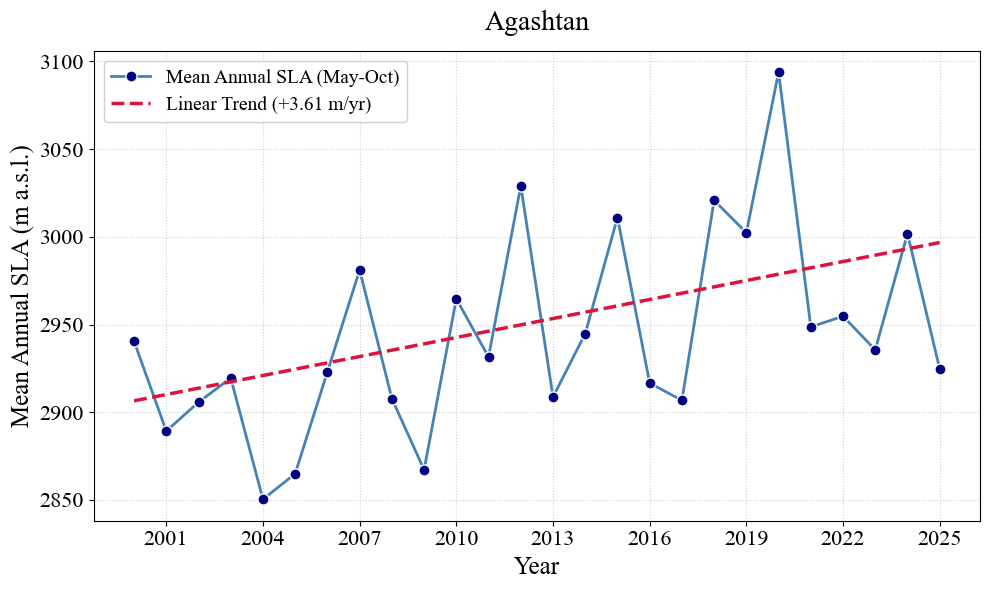

In [6]:
# Font type and size settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "figure.titlesize": 20
})
GLACIER_TO_PLOT = 'Agashtan'
if GLACIER_TO_PLOT in annual_summer_means and GLACIER_TO_PLOT in df_trends['Glacier'].values:

    g_data = annual_summer_means[GLACIER_TO_PLOT]
    stats = df_trends[df_trends['Glacier'] == GLACIER_TO_PLOT].iloc[0]

    trendline_y = (stats['Interpolated SLA Trend (m/yr)'] * g_data.index) + stats['Intercept']

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        g_data.index, g_data.values,
        color='steelblue', linewidth=2,
        marker='o', markersize=8,
        markerfacecolor='navy', markeredgecolor='white',
        zorder=3, label='Mean Annual SLA (May-Oct)'
    )
    ax.plot(
        g_data.index, trendline_y,
        color='crimson', linewidth=2.5, linestyle='--',
        zorder=4, label=f"Linear Trend ({stats['Interpolated SLA Trend (m/yr)']:+.2f} m/yr)"
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Annual SLA (m a.s.l.)")
    ax.set_title(f"{GLACIER_TO_PLOT}", pad=15)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linestyle=':', alpha=0.6, zorder=1)
    ax.legend(loc='upper left', framealpha=0.9)
    plt.tight_layout()
    plt.show()

    #output_path = f"../results/Annual_Trend_Analysis/Annual_Trend_{GLACIER_TO_PLOT}.png"
    #fig.savefig(output_path, dpi=300, bbox_inches='tight')

## 7. Multiple plots annual mean trend
This code plots thea annual mean trend from 2000-2025 for a subset of glaciers selected, all in one figure. Here it is used to create the figures to add in the appendix.

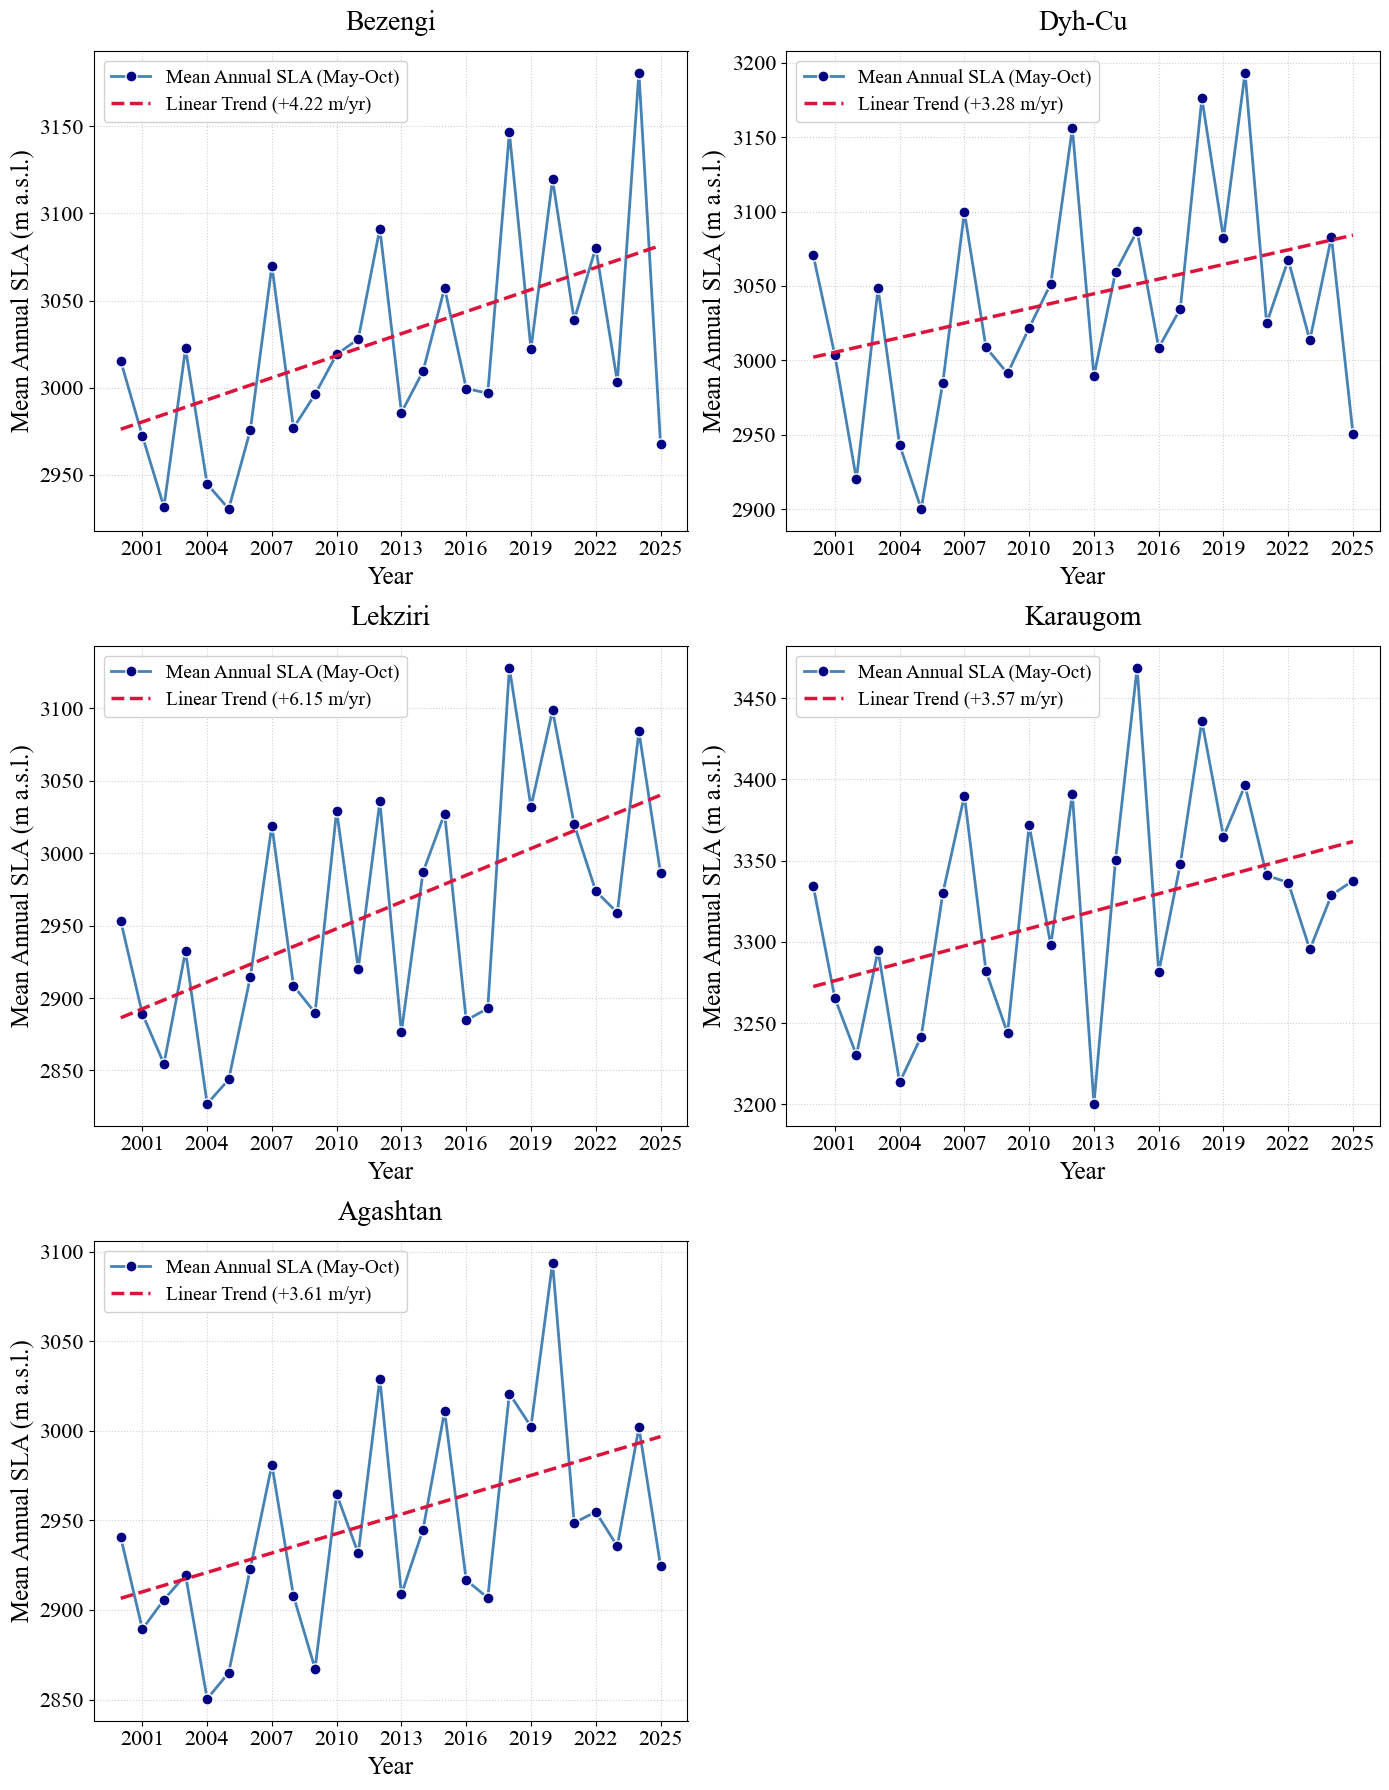

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MaxNLocator

# Font type and size settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "figure.titlesize": 20
})

# Select glaciers
appendix_glaciers = ['Bezengi', 'Dyh-Cu', 'Lekziri', 'Karaugom', 'Agashtan']

# 3x2 grid (6th subplot hidden)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, glacier in enumerate(appendix_glaciers):
    ax = axes[i]

    if glacier in annual_summer_means and glacier in df_trends['Glacier'].values:
        g_data = annual_summer_means[glacier]
        stats = df_trends[df_trends['Glacier'] == glacier].iloc[0]

        trendline_y = (stats['Interpolated SLA Trend (m/yr)'] * g_data.index) + stats['Intercept']

        # Annual mean line
        ax.plot(
            g_data.index, g_data.values,
            color='steelblue', linewidth=2,
            marker='o', markersize=8,
            markerfacecolor='navy', markeredgecolor='white',
            zorder=3, label='Mean Annual SLA (May-Oct)'
        )

        # Trend line
        ax.plot(
            g_data.index, trendline_y,
            color='crimson', linewidth=2.5, linestyle='--',
            zorder=4, label=f"Linear Trend ({stats['Interpolated SLA Trend (m/yr)']:+.2f} m/yr)"
        )

        ax.set_xlabel("Year")
        ax.set_ylabel("Mean Annual SLA (m a.s.l.)")
        ax.set_title(f"{glacier}", pad=15)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, linestyle=':', alpha=0.6, zorder=1)
        ax.legend(loc='upper left', framealpha=0.9)

    else:
        ax.text(0.5, 0.5, f'No data for {glacier}', ha='center', va='center')

# Hide 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Export
output_path = '../Results/Annual_Trend_Analysis/Appendix_Annual_Trends.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')

## 6. Annual Mean Regional Anomalies Plot
To compare trends across glaciers with different absolute elevations, each glacier's annual mean SLA is normalised by subtracting its long-term mean, resulting in anomaly values centred around zero. This allows comparison of interannual variability and directional change across Caneri, Bezengi, and Dyh-Cu (three geographically close glaciers).

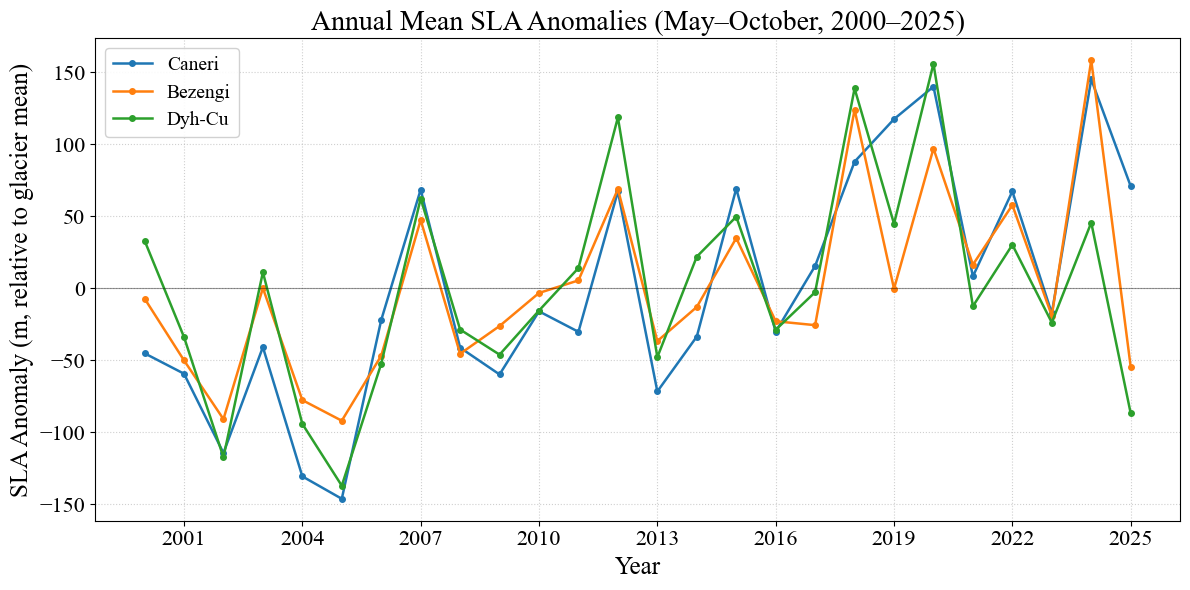

In [7]:
# Font type and size settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "figure.titlesize": 20
})
study_glaciers = ['Caneri', 'Bezengi', 'Dyh-Cu']
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 6))

for i, glacier in enumerate(study_glaciers):
    if glacier not in annual_summer_means:
        continue
    g_data = annual_summer_means[glacier]
    g_normalized = g_data - g_data.mean()
    ax.plot(
        g_normalized.index, g_normalized.values,
        color=colors[i], linewidth=1.8,
        marker='o', markersize=4,
        label=glacier
    )

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("SLA Anomaly (m, relative to glacier mean)")
ax.set_title("Annual Mean SLA Anomalies (May–October, 2000–2025)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

#output_path = "../results/Annual_Trend_Analysis/Regional_SLA_Anomalies.png"
#fig.savefig(output_path, dpi=300, bbox_inches='tight')

## 7. Monthly Mean Trend Plot
The monthly trend results are visualised as a heatmap with glaciers as rows and melt season months (May–October) as columns. Each cell shows the SLA trend in m/yr, colour-coded from blue (negative) to red (positive). Trends that are statistically significant (p < 0.05) are marked with an asterisk (*).

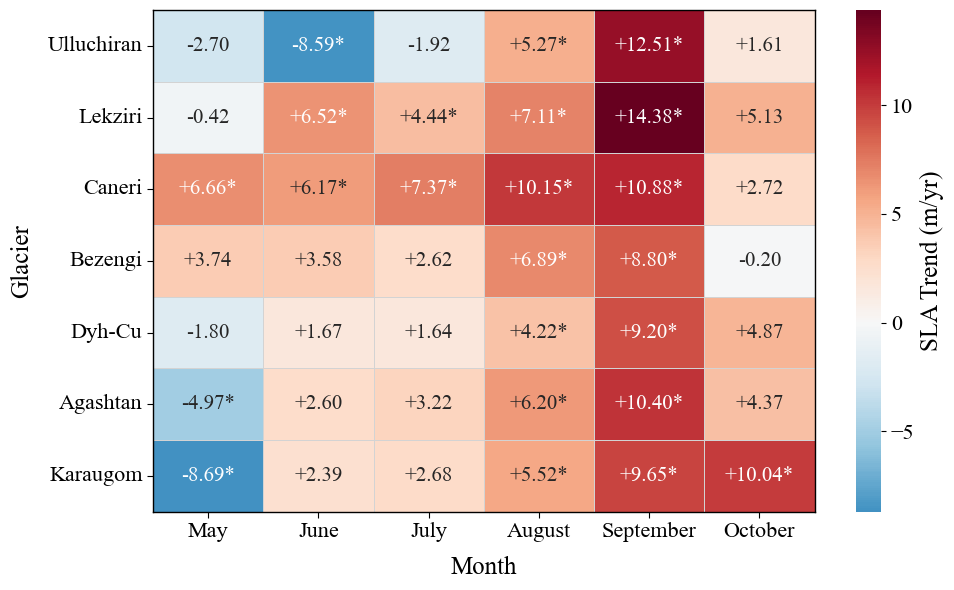

In [8]:
import seaborn as sns
# Font type and size settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 13,
    "figure.titlesize": 20
})
study_glaciers = ['Ulluchiran', 'Lekziri', 'Caneri', 'Bezengi', 'Dyh-Cu', 'Agashtan', 'Karaugom']
month_order = ['May', 'June', 'July', 'August', 'September', 'October']

df_monthly_trends['Significant (p<0.05)?'] = df_monthly_trends['P-value'].apply(
    lambda p: 'Yes' if p < 0.05 else 'No'
)
df_study = df_monthly_trends[df_monthly_trends['Glacier'].isin(study_glaciers)]

heatmap_data = df_study.pivot(
    index='Glacier', columns='Month Name', values='SLA Trend (m/yr)'
).reindex(index=study_glaciers, columns=month_order)

sig_data = df_study.pivot(
    index='Glacier', columns='Month Name', values='Significant (p<0.05)?'
).reindex(index=study_glaciers, columns=month_order)

annot_data = pd.DataFrame(index=heatmap_data.index, columns=heatmap_data.columns)
for glacier in study_glaciers:
    for month in month_order:
        val = heatmap_data.loc[glacier, month]
        sig = sig_data.loc[glacier, month]
        if pd.isna(val):
            annot_data.loc[glacier, month] = 'N/A'
        else:
            star = '*' if sig == 'Yes' else ''
            annot_data.loc[glacier, month] = f"{val:+.2f}{star}"

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt="",
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    linecolor='lightgrey',
    cbar_kws={'label': 'SLA Trend (m/yr)'},
    annot_kws={'size': 15},
    ax=ax
)
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(left=True, bottom=True, length=4, color='black')
ax.set_xlabel("Month", labelpad=10)
ax.set_ylabel("Glacier", labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#output_path = "../results/Monthly_trend_analysis/Monthly_Heatmap_MatchedStyle.png"
#fig.savefig(output_path, dpi=300, bbox_inches='tight')